# Process the data results from Java

In [56]:
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
import math

In [57]:
model = "Model"
stage = "Stage"
alpha = "alpha"
dm_eta = "DM(ETA)"
rs = "RS"
command = "DM/"
file_store_path = "/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/" + command
data_file_name = "2025-01-03.csv"
result_path = "Result/"

In [58]:
def transform_alpha_table(data: pd.DataFrame, metric: str = "Obj") -> pd.DataFrame:
    df = data.copy()
    # ---------- Step 1: 提取 alpha ----------
    alpha_list = []
    for s in df[model]:
        if isinstance(s, str) and s.startswith("RS-"):
            alpha_val = float(s.split("-")[1])
            alpha_list.append(alpha_val)
        else:
            alpha_list.append(None)  # 不满足条件的行赋值为 None
    df[alpha] = alpha_list
    # ---------- Step 2: 读取 DM(ETA), DM(PTA) ----------
    model_list = df[model].tolist()
    dm_eta_val = df.loc[df[model] == dm_eta, metric].iloc[0]
    # ---------- Step 3: 仅保留 RS(PTA)-α ----------
    df_rs = df[df[alpha].notna()].copy()
    # ---------- Step 4: 生成输出结构 ----------
    result = pd.DataFrame({
        alpha: df_rs[alpha].astype(float),
        dm_eta: dm_eta_val,
        rs: df_rs[metric].astype(float)
    })
    # ---------- Step 5: 排序 ----------
    result = result.sort_values(alpha).reset_index(drop=True)
    return result

In [59]:
def plot(result, y_label, ax):
    ax.plot(result[alpha], result[dm_eta], marker='o', label=dm_eta)
    ax.plot(result[alpha], result[rs], marker='o', label=rs)
    ax.set_xlabel("alpha")
    ax.set_title(y_label)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

In [60]:
data = pd.read_csv(file_store_path + "CSV/" + data_file_name)
data["Model"] = data["Model"].str.replace(r'-\d+$', '', regex=True)
mask_rs = data["Model"].str.startswith("RS(PTA)")
data.loc[mask_rs, "Model"] = data.loc[mask_rs, "Model"].str.replace("(PTA)", "", regex=False)
indicators = list(data.columns)
idx_begin = data.columns.get_loc("TP_R0.5_T0")
idx_end = data.columns.get_loc("STD_R1.0_T15")
indicator_cols = indicators[idx_begin:idx_end+1]

base_index = ["TP", "TE", "WT"]
quan_index = ["Var", "Cvar"]
indicator_cols = [f"{i}_R{r}_T{t}" for i in base_index for r in [1.0] for t in [0, 5, 10, 15]] + [f"{i}_R{r}_E{e}" for i in quan_index for r in [1.0] for e in [0.2, 0.5, 0.8, 0.9]]



group_data = (data.groupby([model, stage])[indicator_cols]
              .mean()
              .reset_index())

In [61]:
group_data

,Model,Stage,TP_R1.0_T0,TP_R1.0_T5,TP_R1.0_T10,TP_R1.0_T15,TE_R1.0_T0,TE_R1.0_T5,TE_R1.0_T10,TE_R1.0_T15,...,WT_R1.0_T10,WT_R1.0_T15,Var_R1.0_E0.2,Var_R1.0_E0.5,Var_R1.0_E0.8,Var_R1.0_E0.9,Cvar_R1.0_E0.2,Cvar_R1.0_E0.5,Cvar_R1.0_E0.8,Cvar_R1.0_E0.9
0,DM(ETA),1,0.800000,0.644444,0.577778,0.488889,15.131778,11.544444,8.496667,5.804889,...,30.370000,25.370000,1.410667,14.290000,25.420667,32.667333,18.914722,25.540833,34.776667,37.893333
1,DM(ETA),2,1.000000,1.000000,1.000000,1.000000,44.732926,39.732926,34.732926,29.732926,...,52.786667,47.786667,36.928000,42.696667,52.050000,55.774000,47.849140,51.613111,57.953889,61.146667
2,RS-1.01,1,0.777778,0.622222,0.511111,0.400000,15.289778,11.748222,8.952000,6.574000,...,37.553333,32.553333,1.058667,12.056667,30.244000,35.514000,17.751278,26.772500,39.458889,41.738333
3,RS-1.01,2,1.000000,1.000000,1.000000,1.000000,44.496722,39.496722,34.496722,29.496722,...,54.196667,49.196667,36.623333,42.430000,50.803333,56.785667,47.774206,51.513333,58.631667,62.700000
4,RS-1.015,1,0.800000,0.644444,0.511111,0.422222,15.232889,11.556000,8.746000,6.448667,...,40.433333,35.433333,1.893333,12.110000,27.049333,34.859333,19.041111,26.376667,39.763333,43.508333
5,RS-1.015,2,1.000000,1.000000,1.000000,1.000000,44.685796,39.685796,34.685796,29.685796,...,50.700000,45.700000,38.708000,42.430000,51.404000,56.042333,47.866640,51.262889,56.809444,58.990000
6,RS-1.02,1,0.755556,0.644444,0.488889,0.422222,15.448222,11.945778,9.209556,6.894222,...,46.270000,41.270000,0.162667,10.310000,26.185333,36.359333,16.667500,27.098333,42.262222,48.516667
7,RS-1.02,2,1.000000,1.000000,1.000000,1.000000,44.830685,39.830685,34.830685,29.830685,...,49.210000,44.210000,37.181333,43.533333,54.204000,55.242667,48.154471,52.310222,56.558333,57.636667
8,RS-1.025,1,0.777778,0.644444,0.488889,0.444444,15.396889,11.823556,8.954444,6.591333,...,39.860000,34.860000,0.981333,11.753333,27.847333,36.188000,17.971389,26.751250,40.352222,44.203333
9,RS-1.025,2,1.000000,1.000000,1.000000,1.000000,44.564981,39.564981,34.564981,29.564981,...,53.083333,48.083333,36.940000,42.420000,51.623333,55.841000,47.869749,52.080222,58.316111,60.543333


In [62]:
def select_stage_proportion(nstage):
    if isinstance(nstage, list):
        # 如果是列表，用 isin
        group_first = group_data[group_data[stage].isin(nstage)]
    else:
        # 如果是单值，正常相等判断
        group_first = group_data[group_data[stage] == nstage]
    pivot_df = group_first.pivot_table(
    index=model,
    values=indicator_cols,
    aggfunc='mean'
    )
    pivot_df = pivot_df.reset_index()
    # ----------------------------
    # Step 1: 获取 DM(ETA) 那一行的指标向量
    # ----------------------------
    dm_eta_row = pivot_df[pivot_df[model] == dm_eta].iloc[0]

    # 除 Model 列外的所有指标
    metric_cols = pivot_df.columns.tolist()
    metric_cols.remove(model)

    # ----------------------------
    # Step 2: 标准化
    # ----------------------------
    pivot_df_normalized = pivot_df.copy()
    pivot_df_normalized[metric_cols] = pivot_df[metric_cols] / dm_eta_row[metric_cols]

    # DONE
    # pivot_df_normalized.to_csv(file_store_path + f"stage-{nstage}-proportion-{proportion}.csv", index=False)
    return pivot_df_normalized

In [63]:
def plot_subplots(nstage):
    pivot_df_normalized = select_stage_proportion(nstage)
    pivot_df_normalized.to_csv(result_path + f"stage-{nstage}.csv", index=False)
    # print(pivot_df_normalized)
    n = len(indicator_cols)
    rows = math.ceil(math.sqrt(n))
    cols = math.ceil(n / rows)

    print(f"plot {n} subplots, layout = {rows} × {cols}")
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = axes.flatten()
    for idx, indic in enumerate(indicator_cols):
        result = transform_alpha_table(pivot_df_normalized, metric=indic)
        plot(result, indic, axes[idx])

    # 5. 如果子图数量小于网格数量，隐藏多余的 subplot
    for j in range(len(indicator_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.suptitle(f"stage-{nstage}")
    # plt.savefig(file_store_path + f"stage-{nstage}-proportion-{proportion}.jpg", dpi = 500)
    plt.show()

------ is plotting stage [1, 2] ------
plot 20 subplots, layout = 5 × 4


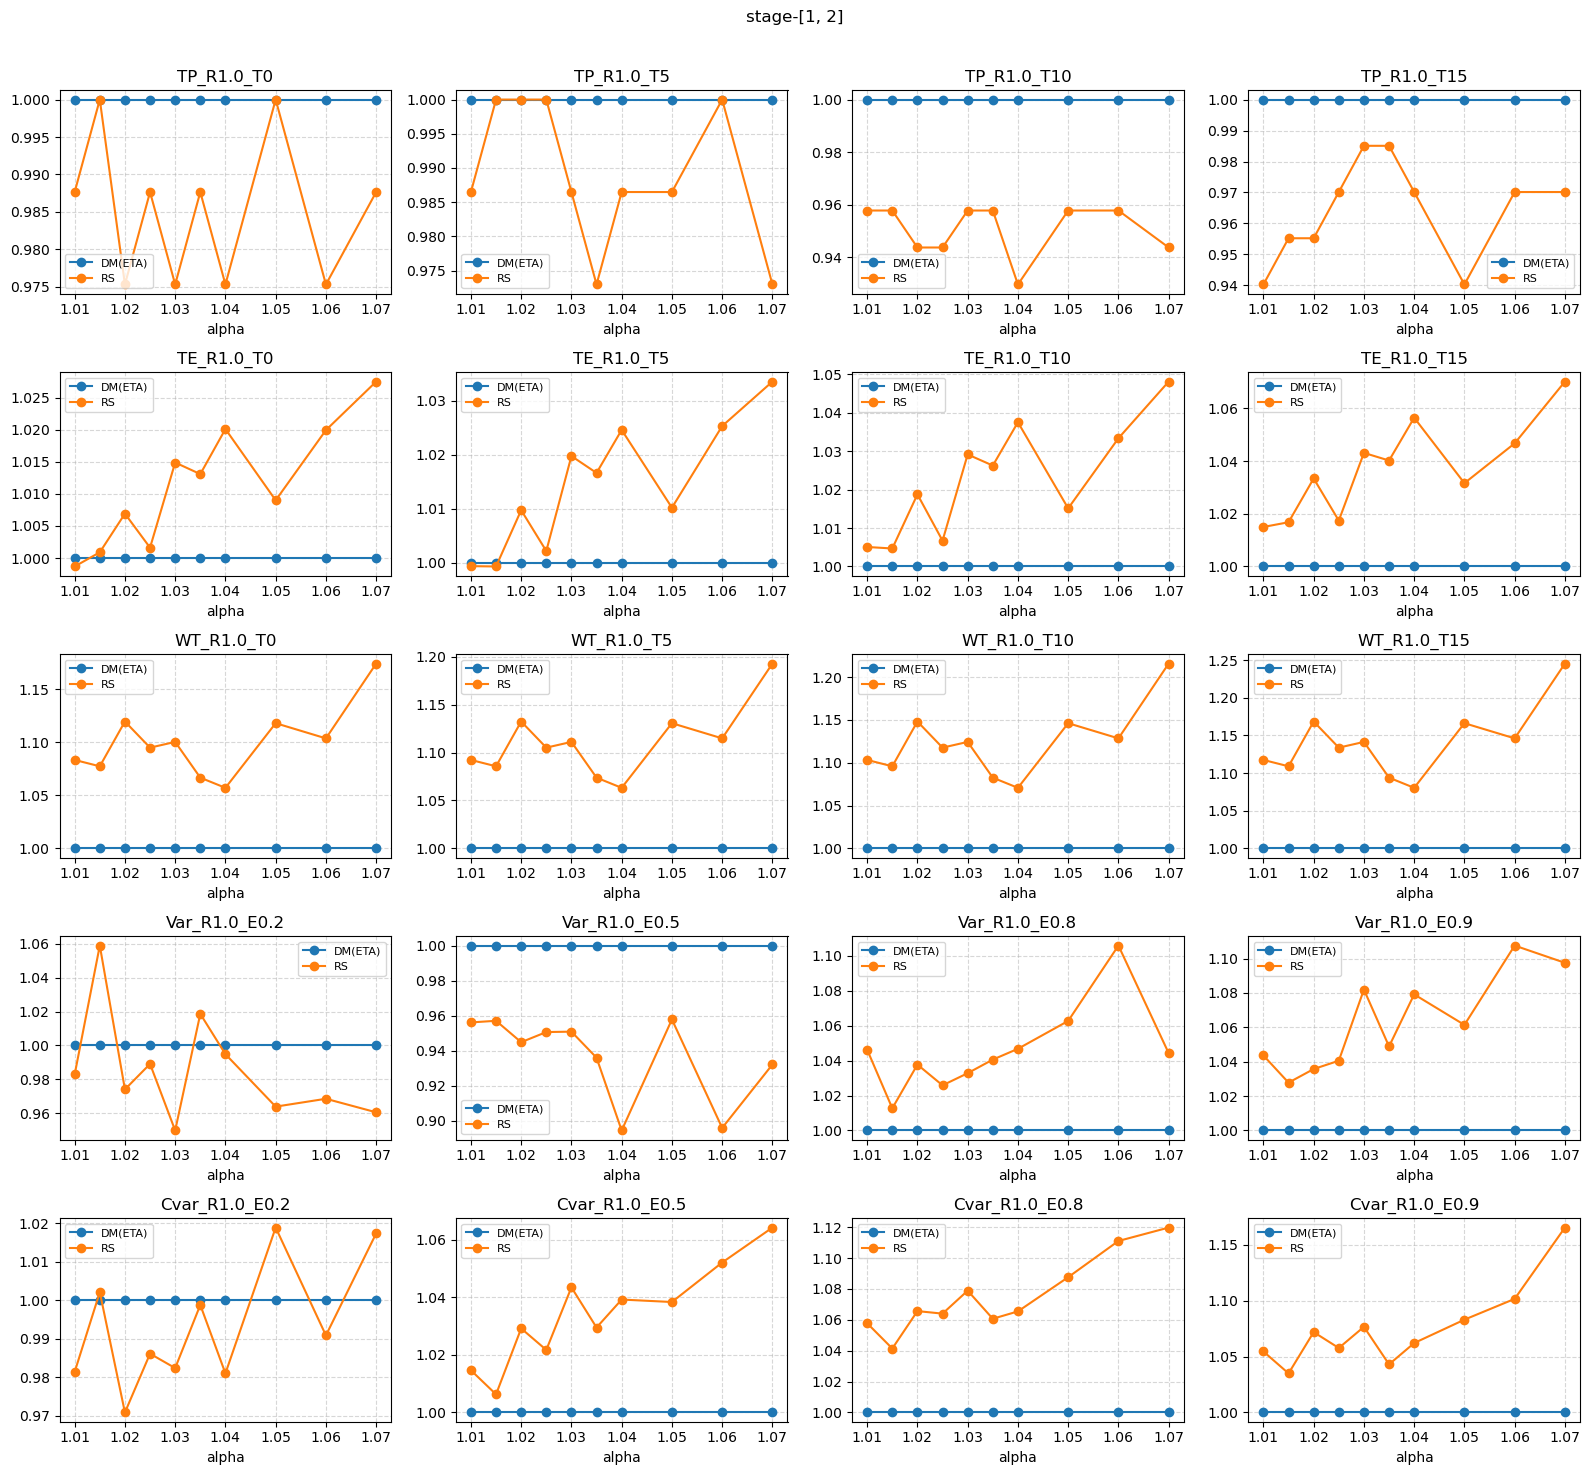

In [65]:
for nstage in [[1, 2]]:
    print(f"------ is plotting stage {nstage} ------")
    plot_subplots(nstage)

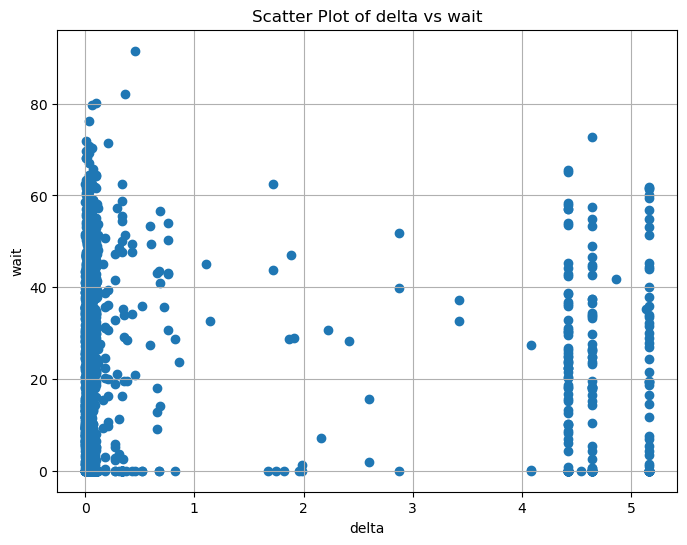

In [ ]:
df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[df["delta"] < 6]
# 绘制散点图
plt.figure(figsize=(8, 6))
plt.scatter(df["delta"], df["wait"])


# 设置坐标轴标签
plt.xlabel("delta")
plt.ylabel("wait")
plt.title("Scatter Plot of delta vs wait")

# 显示网格
plt.grid(True)

# 显示图像
plt.show()

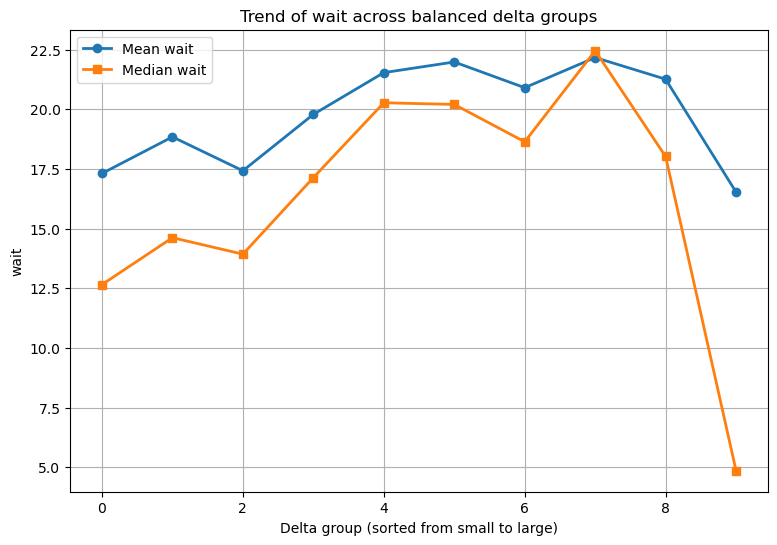

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[["delta", "wait"]].dropna().copy()

df = df.sort_values("delta").reset_index(drop=True)
num_groups = 10
df["delta_group_id"] = pd.qcut(df.index, q=num_groups, labels=False)

grouped = df.groupby("delta_group_id").agg(
    delta_min=("delta", "min"),
    delta_max=("delta", "max"),
    delta_mean=("delta", "mean"),
    wait_mean=("wait", "mean"),
    wait_median=("wait", "median"),
    count=("wait", "size")
).reset_index()

plt.figure(figsize=(9, 6))
plt.plot(grouped["delta_group_id"], grouped["wait_mean"], marker="o", linewidth=2, label="Mean wait")
plt.plot(grouped["delta_group_id"], grouped["wait_median"], marker="s", linewidth=2, label="Median wait")

plt.xlabel("Delta group (sorted from small to large)")
plt.ylabel("wait")
plt.title("Trend of wait across balanced delta groups")
plt.grid(True)
plt.legend()
plt.show()

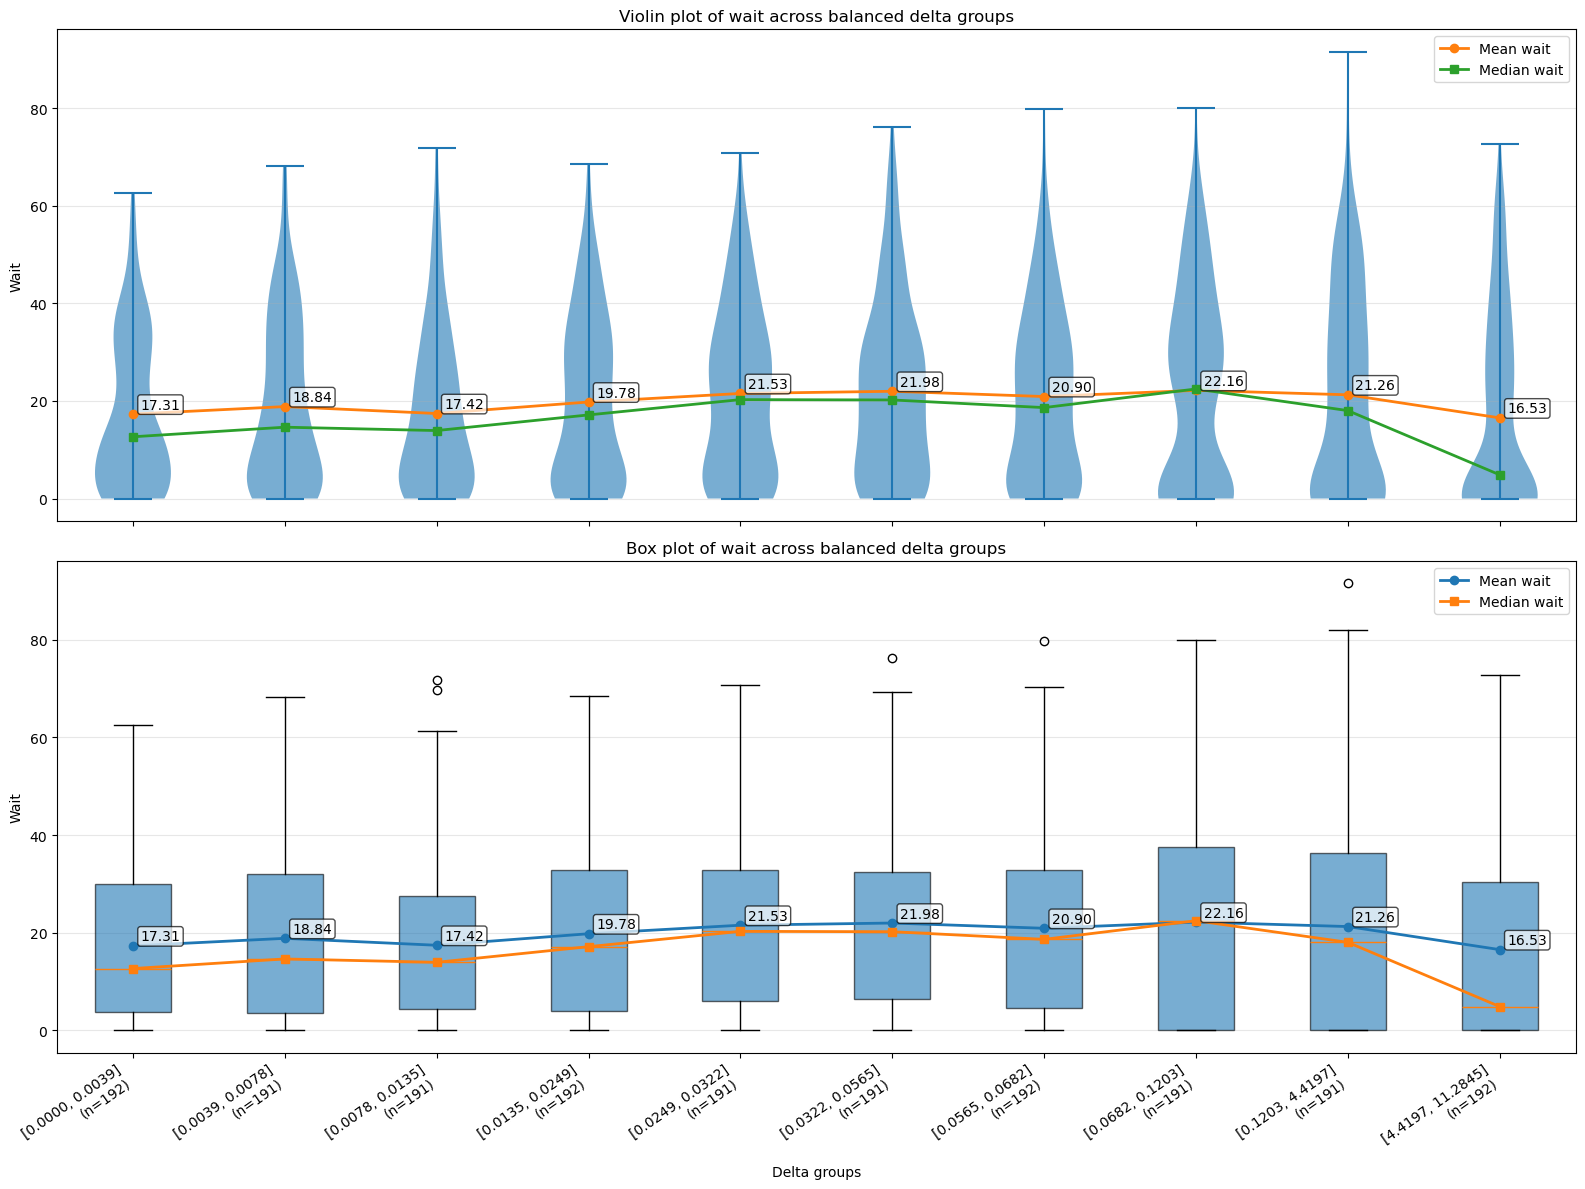

   delta_group_id                 group_label  delta_mean  wait_mean  \
0               0   [0.0000, 0.0039]\n(n=192)    0.001579  17.310104   
1               1   [0.0039, 0.0078]\n(n=191)    0.006974  18.841780   
2               2   [0.0078, 0.0135]\n(n=191)    0.011003  17.423246   
3               3   [0.0135, 0.0249]\n(n=192)    0.020338  19.783542   
4               4   [0.0249, 0.0322]\n(n=191)    0.030431  21.532251   
5               5   [0.0322, 0.0565]\n(n=191)    0.041383  21.978429   
6               6   [0.0565, 0.0682]\n(n=192)    0.062142  20.901458   
7               7   [0.0682, 0.1203]\n(n=191)    0.091195  22.164293   
8               8   [0.1203, 4.4197]\n(n=191)    1.753350  21.257435   
9               9  [4.4197, 11.2845]\n(n=192)    4.985931  16.528385   

   wait_median  count  
0       12.655    192  
1       14.620    191  
2       13.930    191  
3       17.135    192  
4       20.270    191  
5       20.200    191  
6       18.635    192  
7       22.450 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[["delta", "wait"]].dropna().copy()

# 按 delta 排序
df = df.sort_values("delta").reset_index(drop=True)

# 等频分组：保证每组样本数尽量接近
num_groups = 10
df["delta_group_id"] = pd.qcut(df.index, q=num_groups, labels=False)

# 分组统计
grouped = df.groupby("delta_group_id").agg(
    delta_min=("delta", "min"),
    delta_max=("delta", "max"),
    delta_mean=("delta", "mean"),
    wait_mean=("wait", "mean"),
    wait_median=("wait", "median"),
    count=("wait", "size")
).reset_index()

# 横轴标签
grouped["group_label"] = grouped.apply(
    lambda row: f"[{row['delta_min']:.4f}, {row['delta_max']:.4f}]\n(n={int(row['count'])})",
    axis=1
)

# 为作图准备数据
plot_data = [
    df.loc[df["delta_group_id"] == gid, "wait"].values
    for gid in grouped["delta_group_id"]
]

x = np.arange(1, len(grouped) + 1)

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# -------------------------
# 1. Violin plot
# -------------------------
parts = axes[0].violinplot(
    plot_data,
    positions=x,
    showmeans=False,
    showmedians=False,
    showextrema=True
)

for pc in parts["bodies"]:
    pc.set_alpha(0.6)

axes[0].plot(x, grouped["wait_mean"], marker="o", linewidth=2, label="Mean wait")
axes[0].plot(x, grouped["wait_median"], marker="s", linewidth=2, label="Median wait")

for xi, yi in zip(x, grouped["wait_mean"]):
    axes[0].text(
        xi + 0.05, yi + 0.5, f"{yi:.2f}",
        fontsize=10,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
    )

axes[0].set_ylabel("Wait")
axes[0].set_title("Violin plot of wait across balanced delta groups")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

# -------------------------
# 2. Box plot
# -------------------------
bp = axes[1].boxplot(
    plot_data,
    positions=x,
    patch_artist=True,
    showmeans=False
)

for box in bp["boxes"]:
    box.set_alpha(0.6)

axes[1].plot(x, grouped["wait_mean"], marker="o", linewidth=2, label="Mean wait")
axes[1].plot(x, grouped["wait_median"], marker="s", linewidth=2, label="Median wait")

for xi, yi in zip(x, grouped["wait_mean"]):
    axes[1].text(
        xi + 0.05, yi + 0.5, f"{yi:.2f}",
        fontsize=10,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(grouped["group_label"], rotation=35, ha="right")
axes[1].set_xlabel("Delta groups")
axes[1].set_ylabel("Wait")
axes[1].set_title("Box plot of wait across balanced delta groups")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# 打印分组统计表
print(grouped[["delta_group_id", "group_label", "delta_mean", "wait_mean", "wait_median", "count"]])

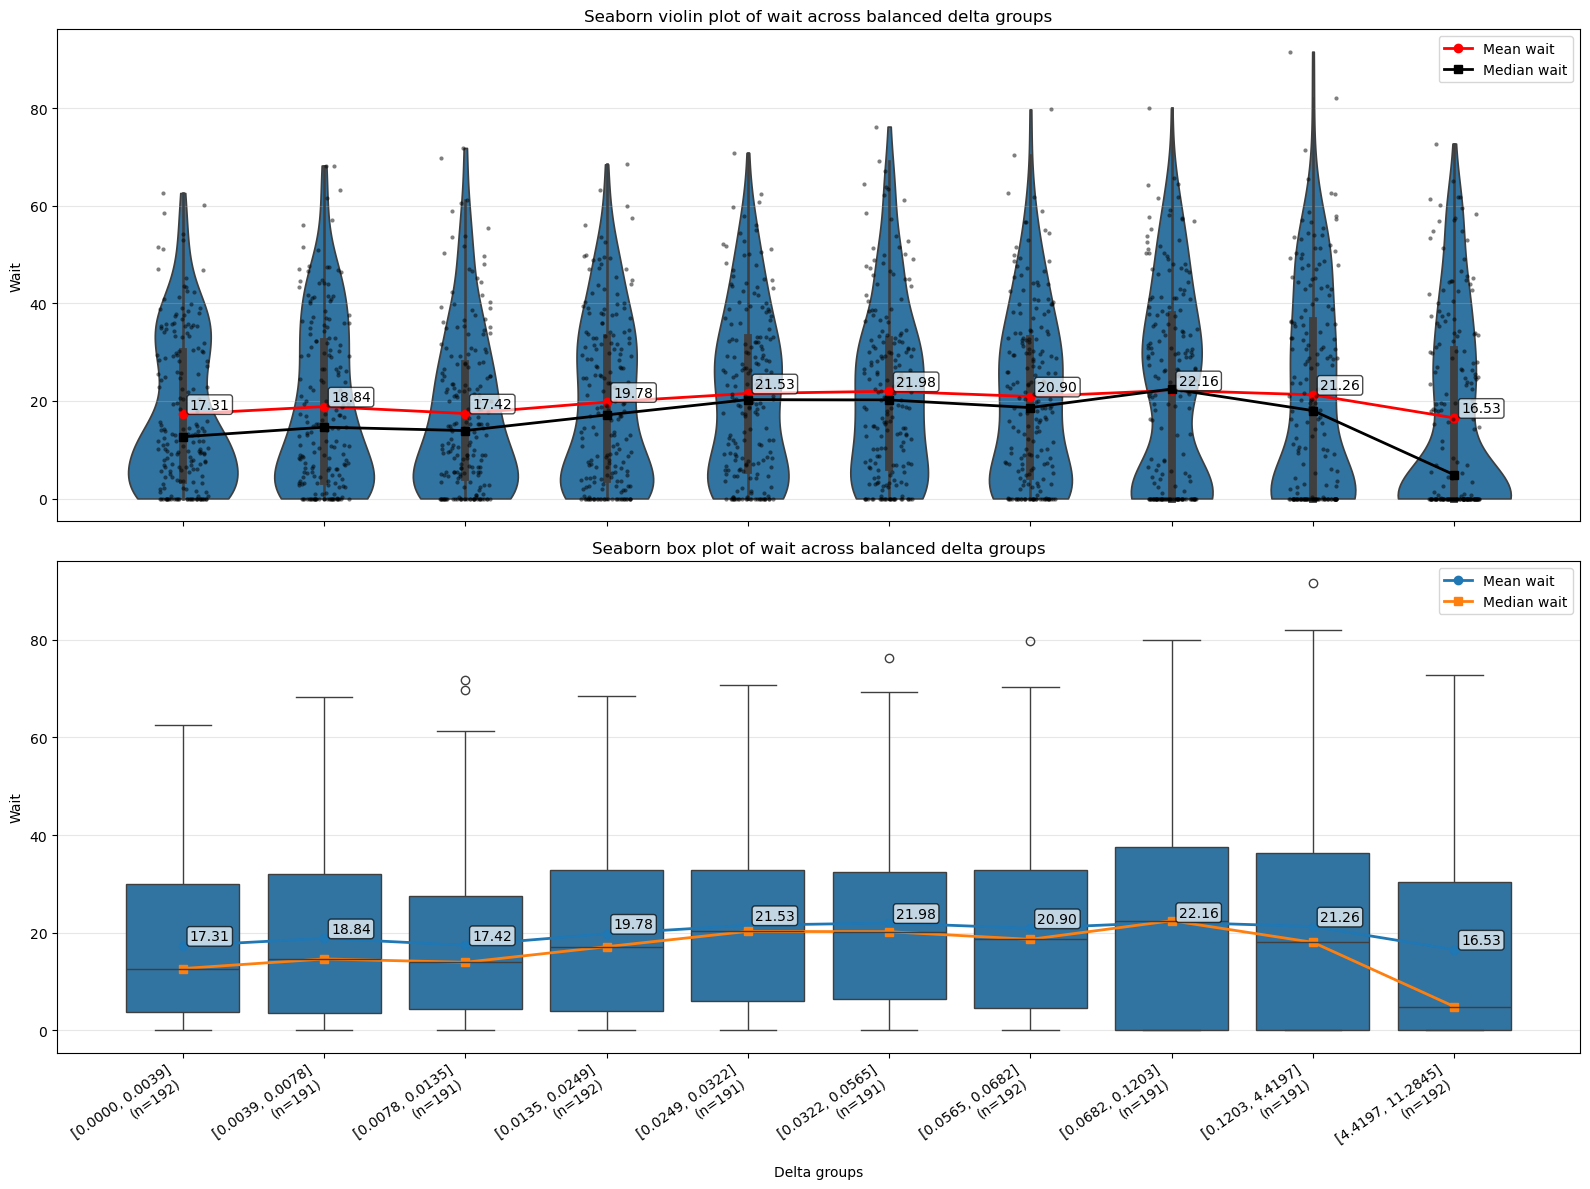

   delta_group_id                 group_label  delta_mean  wait_mean  \
0               0   [0.0000, 0.0039]\n(n=192)    0.001579  17.310104   
1               1   [0.0039, 0.0078]\n(n=191)    0.006974  18.841780   
2               2   [0.0078, 0.0135]\n(n=191)    0.011003  17.423246   
3               3   [0.0135, 0.0249]\n(n=192)    0.020338  19.783542   
4               4   [0.0249, 0.0322]\n(n=191)    0.030431  21.532251   
5               5   [0.0322, 0.0565]\n(n=191)    0.041383  21.978429   
6               6   [0.0565, 0.0682]\n(n=192)    0.062142  20.901458   
7               7   [0.0682, 0.1203]\n(n=191)    0.091195  22.164293   
8               8   [0.1203, 4.4197]\n(n=191)    1.753350  21.257435   
9               9  [4.4197, 11.2845]\n(n=192)    4.985931  16.528385   

   wait_median  count  
0       12.655    192  
1       14.620    191  
2       13.930    191  
3       17.135    192  
4       20.270    191  
5       20.200    191  
6       18.635    192  
7       22.450 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[["delta", "wait"]].dropna().copy()

# 按 delta 排序
df = df.sort_values("delta").reset_index(drop=True)

# 等频分组：保证每组样本数尽量接近
num_groups = 10
df["delta_group_id"] = pd.qcut(df.index, q=num_groups, labels=False)

# 分组统计
grouped = df.groupby("delta_group_id").agg(
    delta_min=("delta", "min"),
    delta_max=("delta", "max"),
    delta_mean=("delta", "mean"),
    wait_mean=("wait", "mean"),
    wait_median=("wait", "median"),
    count=("wait", "size")
).reset_index()

# 横轴标签
grouped["group_label"] = grouped.apply(
    lambda row: f"[{row['delta_min']:.4f}, {row['delta_max']:.4f}]\n(n={int(row['count'])})",
    axis=1
)

# 把标签映射回原始 df，方便 seaborn 直接按类别画图
label_map = dict(zip(grouped["delta_group_id"], grouped["group_label"]))
df["group_label"] = df["delta_group_id"].map(label_map)

# 为了保证 seaborn 画图顺序正确
group_order = grouped.sort_values("delta_group_id")["group_label"].tolist()
x = np.arange(len(group_order))

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# -------------------------
# 1. Seaborn violin plot
# -------------------------
sns.violinplot(
    data=df,
    x="group_label",
    y="wait",
    order=group_order,
    ax=axes[0],
    inner="box",      # 不在小提琴内部画箱线/点
    cut=0            # 不超出实际数据范围
)

sns.stripplot(
    data=df,
    x="group_label",
    y="wait",
    order=group_order,
    ax=axes[0],
    color="black",
    size=3,
    jitter=0.18,
    alpha=0.5
)

# 叠加均值和中位数
axes[0].plot(x, grouped["wait_mean"], marker="o", linewidth=2, color="red", label="Mean wait")
axes[0].plot(x, grouped["wait_median"], marker="s", linewidth=2, color="black",label="Median wait")

# 标注均值
for xi, yi in zip(x, grouped["wait_mean"]):
    axes[0].text(
        xi + 0.05, yi + 0.5, f"{yi:.2f}",
        fontsize=10,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
    )

axes[0].set_ylabel("Wait")
axes[0].set_xlabel("")
axes[0].set_title("Seaborn violin plot of wait across balanced delta groups")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

# -------------------------
# 2. Seaborn box plot
# -------------------------
sns.boxplot(
    data=df,
    x="group_label",
    y="wait",
    order=group_order,
    ax=axes[1]
)

# 叠加均值和中位数
axes[1].plot(x, grouped["wait_mean"], marker="o", linewidth=2, label="Mean wait")
axes[1].plot(x, grouped["wait_median"], marker="s", linewidth=2, label="Median wait")

# 标注均值
for xi, yi in zip(x, grouped["wait_mean"]):
    axes[1].text(
        xi + 0.05, yi + 0.5, f"{yi:.2f}",
        fontsize=10,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
    )

axes[1].set_xlabel("Delta groups")
axes[1].set_ylabel("Wait")
axes[1].set_title("Seaborn box plot of wait across balanced delta groups")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()

# 统一旋转横轴标签
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

plt.tight_layout()
plt.show()

# 打印分组统计表
print(grouped[["delta_group_id", "group_label", "delta_mean", "wait_mean", "wait_median", "count"]])

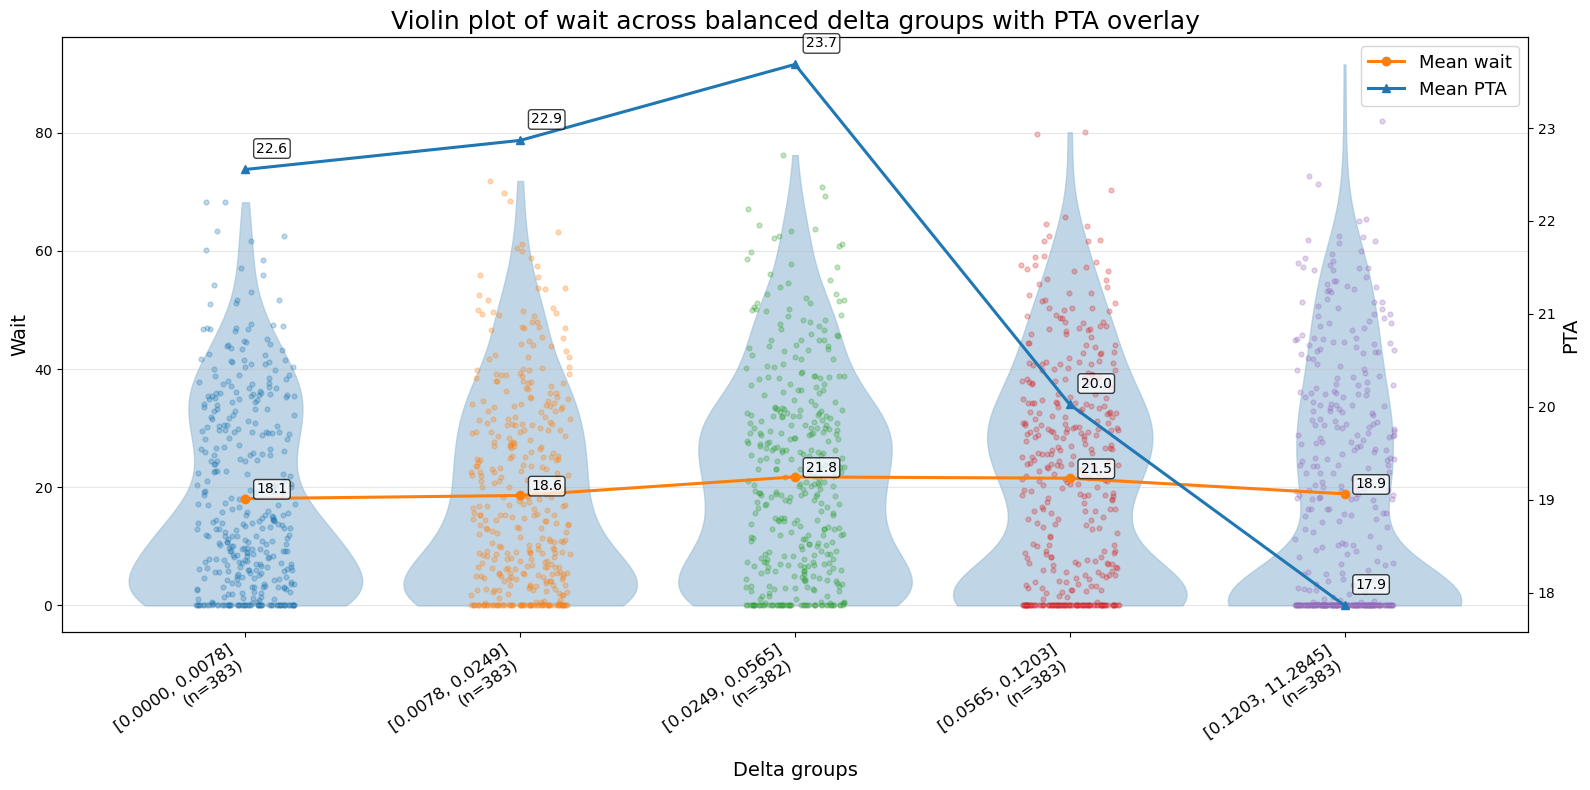

   delta_group_id                 group_label  delta_mean  wait_mean  \
0               0   [0.0000, 0.0078]\n(n=383)    0.004269  18.073943   
1               1   [0.0078, 0.0249]\n(n=383)    0.015682  18.606475   
2               2   [0.0249, 0.0565]\n(n=382)    0.035907  21.755340   
3               3   [0.0565, 0.1203]\n(n=383)    0.076631  21.531227   
4               4  [0.1203, 11.2845]\n(n=383)    3.373861  18.886736   

    pta_mean  count  
0  22.554151    383  
1  22.867050    383  
2  23.684895    382  
3  20.025170    383  
4  17.862742    383  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 读取数据
# =========================
df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[["delta", "wait", "pta"]].dropna().copy()

# =========================
# 按 delta 排序
# =========================
df = df.sort_values("delta").reset_index(drop=True)

# =========================
# 等频分组：保证每组样本数尽量接近
# =========================
num_groups = 5
df["delta_group_id"] = pd.qcut(df.index, q=num_groups, labels=False)

# =========================
# 分组统计：只保留均值
# =========================
grouped = df.groupby("delta_group_id").agg(
    delta_min=("delta", "min"),
    delta_max=("delta", "max"),
    delta_mean=("delta", "mean"),
    wait_mean=("wait", "mean"),
    pta_mean=("pta", "mean"),
    count=("wait", "size")
).reset_index()

# 横轴标签
grouped["group_label"] = grouped.apply(
    lambda row: f"[{row['delta_min']:.4f}, {row['delta_max']:.4f}]\n(n={int(row['count'])})",
    axis=1
)

# 映射回原始 df
label_map = dict(zip(grouped["delta_group_id"], grouped["group_label"]))
df["group_label"] = df["delta_group_id"].map(label_map)

# 保证顺序正确
group_order = grouped.sort_values("delta_group_id")["group_label"].tolist()
x = np.arange(len(group_order))

# 每组 wait 数据
violin_data = [
    df.loc[df["group_label"] == label, "wait"].to_numpy()
    for label in group_order
]

# matplotlib 默认颜色循环
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# =========================
# 作图
# =========================
fig, ax1 = plt.subplots(figsize=(16, 8))

# 1. violin
parts = ax1.violinplot(
    violin_data,
    positions=x,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    widths=0.85
)

for pc in parts["bodies"]:
    pc.set_facecolor("#9ec1da")   # 浅蓝色
    pc.set_edgecolor("#9ec1da")
    pc.set_alpha(0.65)

# 2. 每组散点
rng = np.random.default_rng(2026)
for i, vals in enumerate(violin_data):
    jitter = rng.uniform(-0.18, 0.18, size=len(vals))
    ax1.scatter(
        np.full(len(vals), x[i]) + jitter,
        vals,
        s=12,
        alpha=0.28,
        color=default_colors[i % len(default_colors)]
    )

# 3. 左轴：Mean wait（橙色）
line1, = ax1.plot(
    x,
    grouped["wait_mean"],
    marker="o",
    linewidth=2.2,
    color="tab:orange",
    label="Mean wait"
)

for xi, yi in zip(x, grouped["wait_mean"]):
    ax1.text(
        xi + 0.04,
        yi + 0.4,
        f"{yi:.1f}",
        fontsize=10,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75)
    )

ax1.set_ylabel("Wait", fontsize=14)
ax1.set_xlabel("Delta groups", fontsize=14)
ax1.set_title("Violin plot of wait across balanced delta groups with PTA overlay", fontsize=18)
ax1.grid(True, axis="y", alpha=0.3)

# 4. 右轴：Mean PTA（蓝色）
ax2 = ax1.twinx()
line2, = ax2.plot(
    x,
    grouped["pta_mean"],
    marker="^",
    linewidth=2.2,
    color="tab:blue",
    label="Mean PTA"
)

for xi, yi in zip(x, grouped["pta_mean"]):
    ax2.text(
        xi + 0.04,
        yi + 0.15,
        f"{yi:.1f}",
        fontsize=10,
        ha="left",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75)
    )

ax2.set_ylabel("PTA", fontsize=14)

# 图例：只保留均值
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right", fontsize=13)

# 横轴标签
ax1.set_xticks(x)
ax1.set_xticklabels(group_order, rotation=35, ha="right", fontsize=12)

plt.tight_layout()

# 保存
plt.savefig("delta_grouped_wait_violin_mean_pta_same_style.png", dpi=300, bbox_inches="tight")
plt.show()

# 打印分组统计
print(grouped[["delta_group_id", "group_label", "delta_mean", "wait_mean", "pta_mean", "count"]])

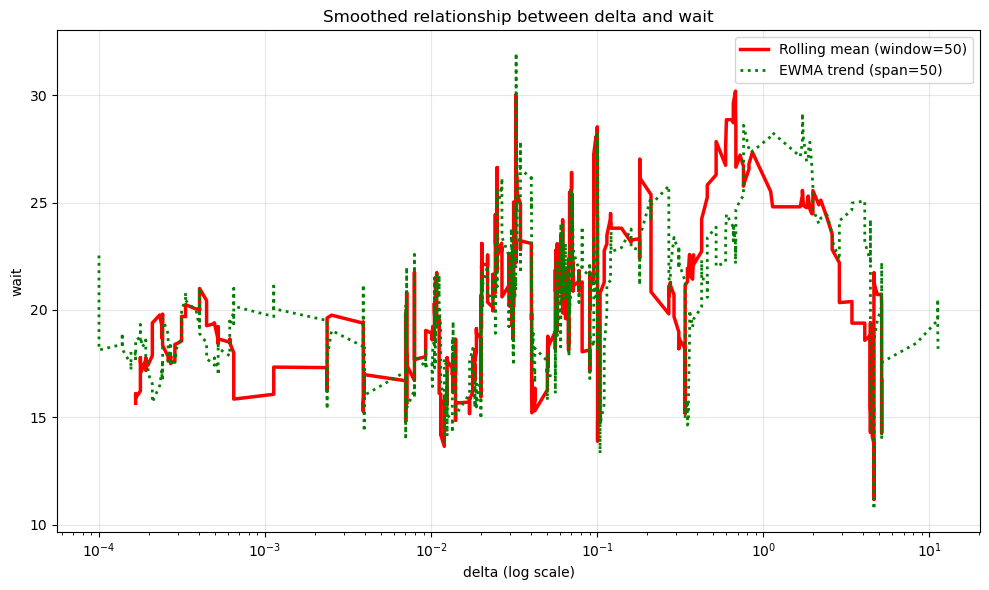

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[["delta", "wait"]].dropna().copy()

# 按 delta 排序
df = df.sort_values("delta").reset_index(drop=True)

window = 50
df["wait_roll_mean"] = df["wait"].rolling(window=window, center=True).mean()
df["wait_roll_median"] = df["wait"].rolling(window=window, center=True).median()
df["wait_smooth"] = df["wait"].ewm(span=window, adjust=False).mean()

# 避免 log(0)
df["delta_plot"] = df["delta"] + 1e-4

plt.figure(figsize=(10, 6))

plt.plot(df["delta_plot"], df["wait_roll_mean"], color="red", linewidth=2.5, label=f"Rolling mean (window={window})")
# plt.plot(df["delta_plot"], df["wait_roll_median"], color="blue", linewidth=2, linestyle="--", label=f"Rolling median (window={window})")
plt.plot(df["delta_plot"], df["wait_smooth"], color="green", linewidth=2, linestyle=":", label=f"EWMA trend (span={window})")

plt.xscale("log")
plt.xlabel("delta (log scale)")
plt.ylabel("wait")
plt.title("Smoothed relationship between delta and wait")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

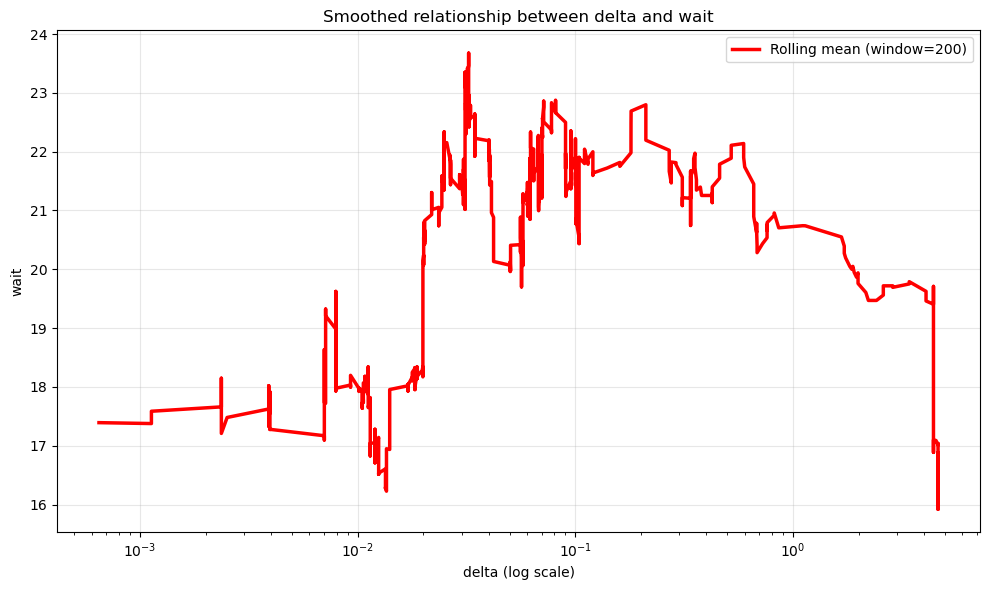

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[["delta", "wait"]].dropna().copy()

# 按 delta 排序
df = df.sort_values("delta").reset_index(drop=True)

# 只看主区间
# df = df[df["delta"] <= 6].copy().reset_index(drop=True)

# 滚动均值
window = 200
df["wait_roll_mean"] = df["wait"].rolling(window=window, center=True).mean()

# 避免 log(0)
df["delta_plot"] = df["delta"] + 1e-4

plt.figure(figsize=(10, 6))
plt.plot(
    df["delta_plot"],
    df["wait_roll_mean"],
    color="red",
    linewidth=2.5,
    label=f"Rolling mean (window={window})"
)

plt.xscale("log")
plt.xlabel("delta (log scale)")
plt.ylabel("wait")
plt.title("Smoothed relationship between delta and wait")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

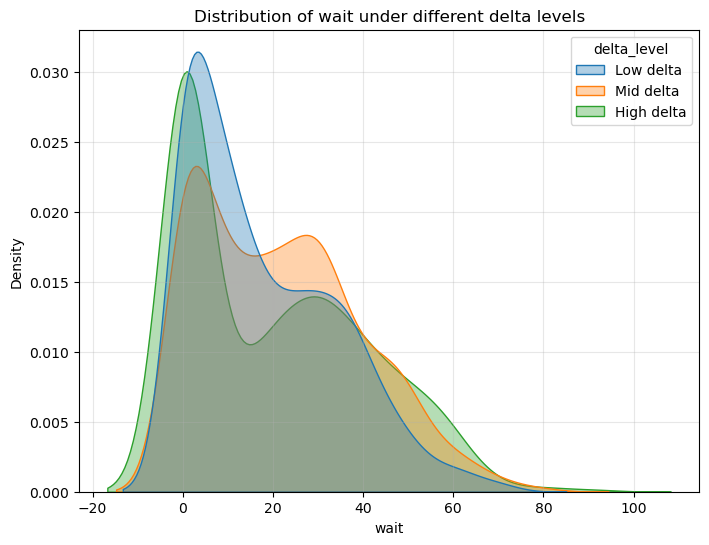

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[["delta", "wait"]].dropna().copy()

df["delta_level"] = pd.qcut(df["delta"], q=3, labels=["Low delta", "Mid delta", "High delta"])

plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x="wait", hue="delta_level", fill=True, common_norm=False, alpha=0.35)
plt.xlabel("wait")
plt.title("Distribution of wait under different delta levels")
plt.grid(True, alpha=0.3)
plt.show()

  delta_level  delta_min  delta_max  delta_mean  count
0   Low delta   0.000000   0.019842    0.008128    671
1   Mid delta   0.019999   0.064284    0.039366    616
2  High delta   0.067157  11.284499    2.094406    627


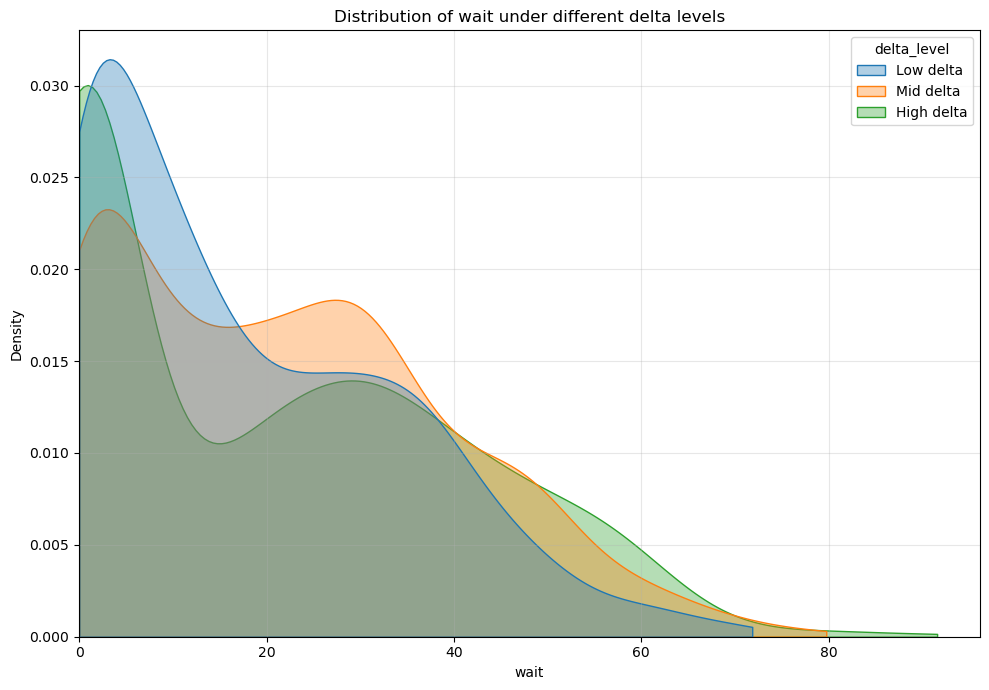

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/CSV/delta_wait.csv")
df = df[["delta", "wait"]].dropna().copy()

# 将 delta 按分位数分成 3 组：低 / 中 / 高
df["delta_level"] = pd.qcut(
    df["delta"],
    q=3,
    labels=["Low delta", "Mid delta", "High delta"]
)

# 查看三组对应的 delta 范围和样本量
grouped = df.groupby("delta_level", observed=False).agg(
    delta_min=("delta", "min"),
    delta_max=("delta", "max"),
    delta_mean=("delta", "mean"),
    count=("delta", "size")
).reset_index()

print(grouped)

# 画不同 delta 水平下 wait 的 KDE 分布图
plt.figure(figsize=(10, 7))
sns.kdeplot(
    data=df,
    x="wait",
    hue="delta_level",
    fill=True,
    common_norm=False,
    alpha=0.35,
    cut=0
)

plt.xlim(left=0)
plt.xlabel("wait")
plt.ylabel("Density")
plt.title("Distribution of wait under different delta levels")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
for nstage in [[1, 2]]:
    proportion = 1
    print(f"------ is plotting stage {nstage} with proportion {proportion} ------")
    plot_subplots(nstage, proportion)

------ is plotting stage [1, 2] with proportion 1 ------


NameError: name 'select_stage_proportion' is not defined

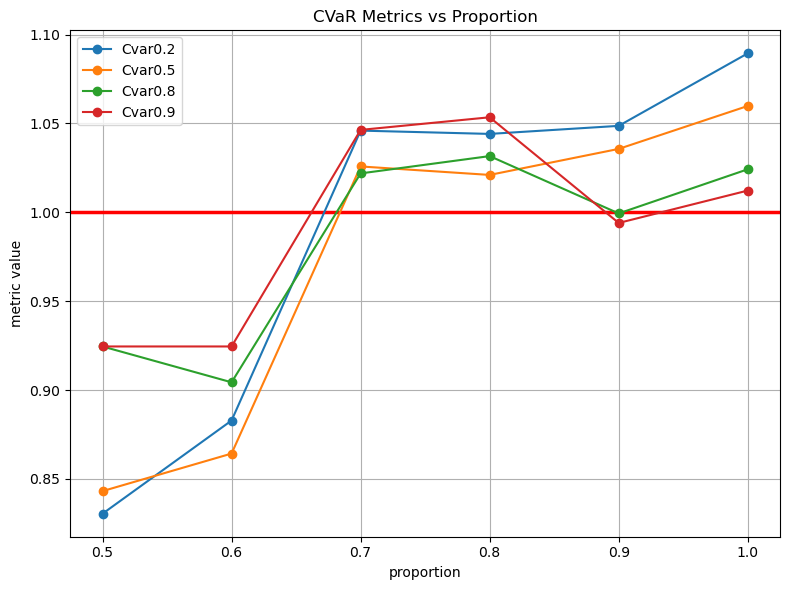

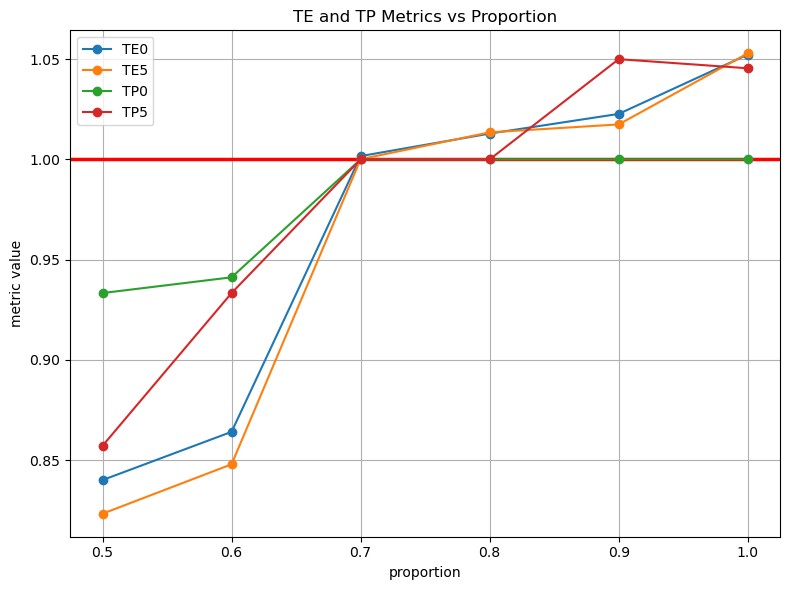

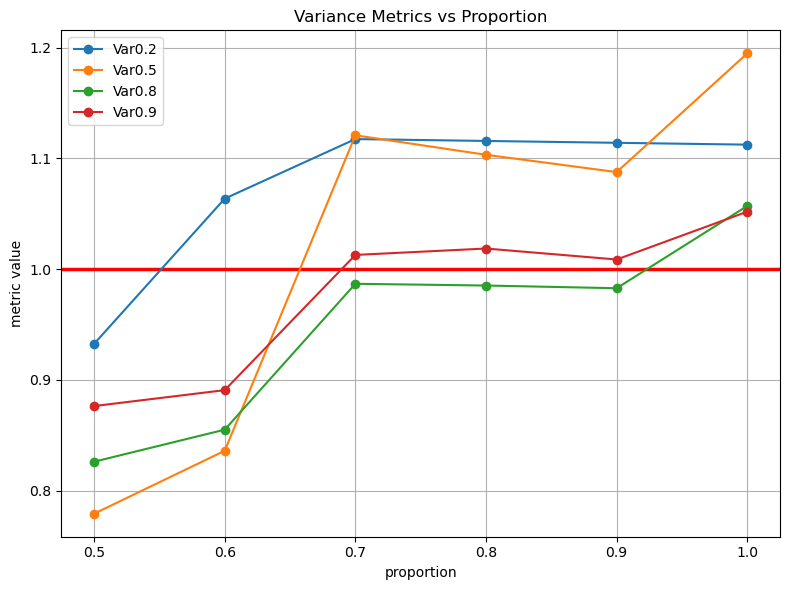

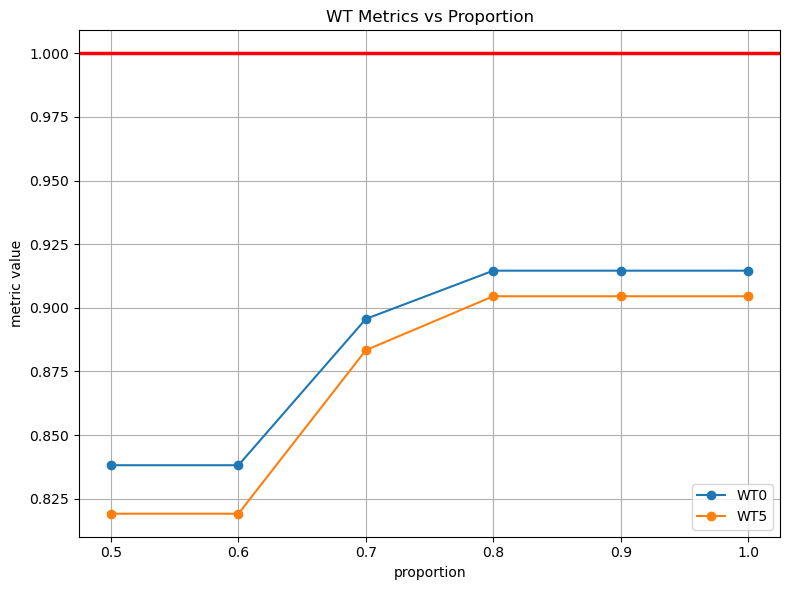

In [183]:
df = pd.read_csv("/Users/zhoubingjie/Nutstore Files/我的坚果云/Code/IDEA/ReliablePortSchedules/Result/Indicator/absolute.csv")
groups = [
    ["Cvar0.2", "Cvar0.5", "Cvar0.8", "Cvar0.9"],
    ["TE0", "TE5", "TP0", "TP5"],
    ["Var0.2", "Var0.5", "Var0.8", "Var0.9"],
    ["WT0", "WT5"]
]

titles = [
    "CVaR Metrics vs Proportion",
    "TE and TP Metrics vs Proportion",
    "Variance Metrics vs Proportion",
    "WT Metrics vs Proportion"
]

# 逐张画图
for group, title in zip(groups, titles):
    plt.figure(figsize=(8, 6))
    plt.axhline(y=1, color="red", linewidth=2.5)
    for col in group:
        plt.plot(df["proportion"], df[col], marker="o", label=col)
    
    plt.xlabel("proportion")
    plt.ylabel("metric value")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()